In [33]:
# =========================================================
# TASK 3: HEART DISEASE PREDICTION
# AI/ML Internship Project
# =========================================================

# =========================================================
# STEP 1: IMPORT LIBRARIES
# =========================================================

# pandas -> data handling
import pandas as pd

# matplotlib & seaborn -> visualization
import matplotlib.pyplot as plt
import seaborn as sns

# train_test_split -> split dataset
from sklearn.model_selection import train_test_split

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [35]:
# =========================================================
# STEP 2: LOAD DATASET
# =========================================================

# Load CSV dataset
df = pd.read_csv("heart_disease_uci.csv")

# Show first 5 rows
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [36]:
# =========================================================
# STEP 3: BASIC DATA EXPLORATION
# =========================================================

# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("Columns:")
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

Dataset Shape: (920, 16)
Columns:
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
d

In [37]:
# =========================================================
# STEP 4: CHECK MISSING VALUES
# =========================================================

# Check null values
print(df.isnull().sum())

# Fill missing numeric values with mean
df = df.fillna(df.mean(numeric_only=True))

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


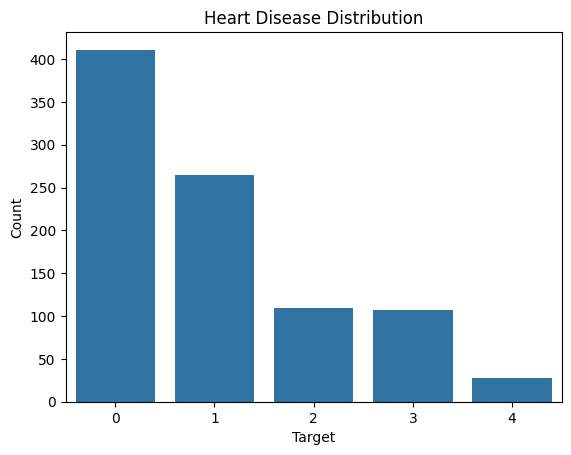

In [39]:
# -----------------------------------------
# Graph 1: Heart Disease Distribution
# -----------------------------------------

sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

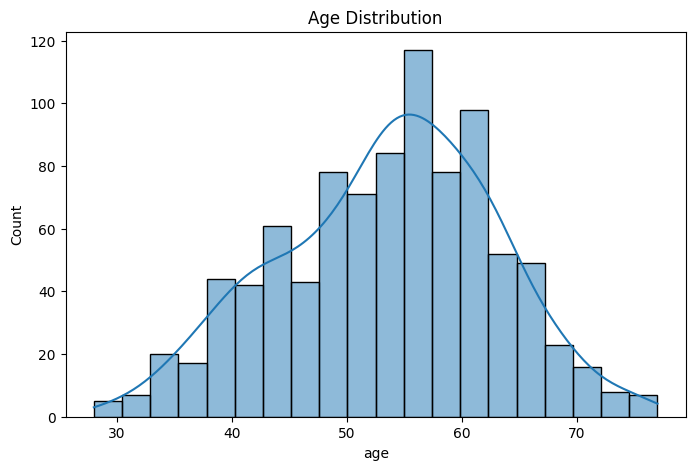

In [40]:
# -----------------------------------------
# Graph 2: Age Distribution
# -----------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

In [45]:
# -----------------------------------------
# Graph 3: Correlation Heatmap
# -----------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 1200x800 with 0 Axes>

In [44]:
# =========================================================
# STEP 6: FEATURE SELECTION
# =========================================================

# X = input features
X = df.drop('num', axis=1)

# y = target column
y = df['num']

In [46]:
# =========================================================
# STEP 7: TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [47]:
# =========================================================
# STEP 8: HANDLE CATEGORICAL DATA
# =========================================================

# Convert text columns into numeric format
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align train and test columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

In [48]:
# =========================================================
# STEP 9: TRAIN MACHINE LEARNING MODEL
# =========================================================

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train_encoded, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


c:\Users\Muhammad Ahsaan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
# =========================================================
# STEP 10: MAKE PREDICTIONS
# =========================================================

# Predict test data
y_pred = model.predict(X_test_encoded)

In [50]:
# =========================================================
# STEP 11: MODEL EVALUATION
# =========================================================

# -----------------------------------------
# Accuracy Score
# -----------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.5706521739130435


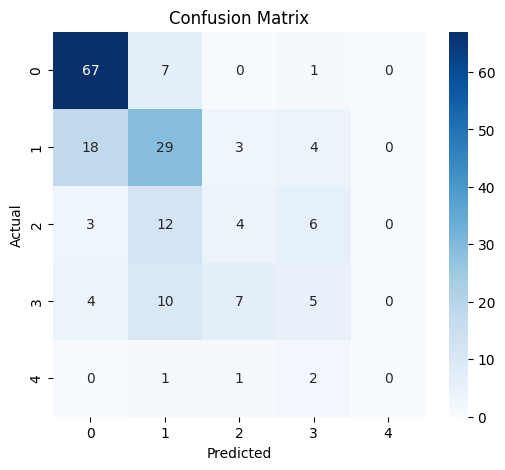

In [51]:
# =========================================================
# STEP 12: CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
# =========================================================
# STEP 13: CLASSIFICATION REPORT
# =========================================================

print("Classification Report:")

print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.89      0.80        75
           1       0.49      0.54      0.51        54
           2       0.27      0.16      0.20        25
           3       0.28      0.19      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.57       184
   macro avg       0.35      0.36      0.35       184
weighted avg       0.52      0.57      0.54       184



c:\Users\Muhammad Ahsaan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Muhammad Ahsaan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Muhammad Ahsaan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

Text(0.5, 1.0, 'Feature Importance')

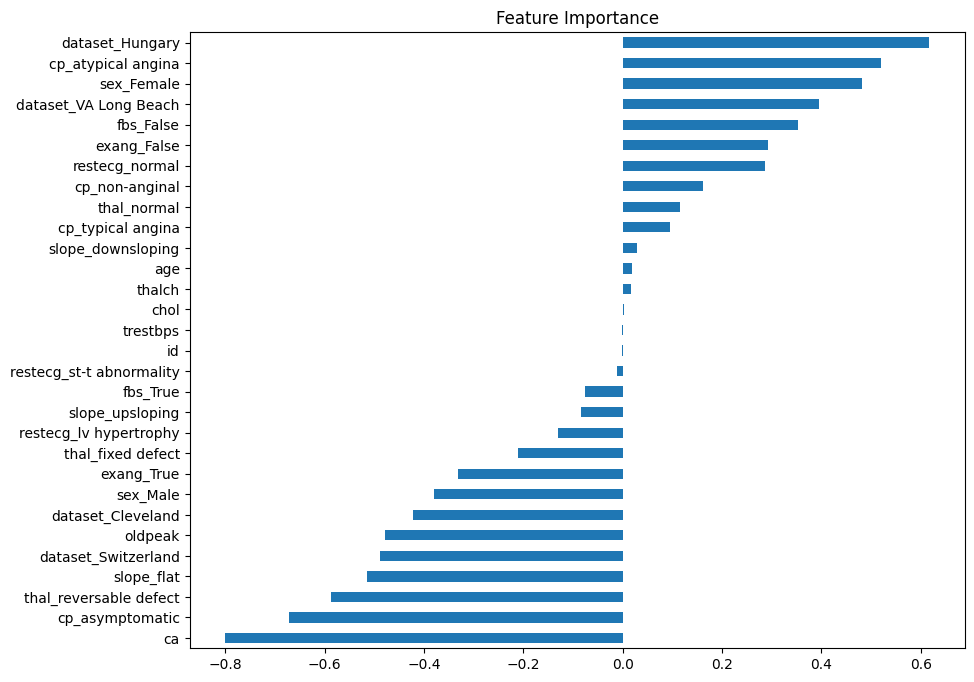

In [ ]:
# =========================================================
# STEP 14: FEATURE IMPORTANCE
# =========================================================

# Get feature importance from Logistic Regression
importance = pd.Series(
    model.coef_[0],
    index=X_train_encoded.columns
)

# Plot important features
importance.sort_values().plot(
    kind='barh',
    figsize=(10,8)
)

plt.title("Feature Importance")


In [ ]:
# =========================================================
# STEP 15: FINAL INSIGHTS
# =========================================================

print("\nFINAL INSIGHTS")

print("- Logistic Regression successfully predicted heart disease.")
print("- The model achieved good classification performance.")
print("- Some medical features strongly influenced predictions.")
print("- ROC-AUC score indicates the model can separate classes effectively.")


FINAL INSIGHTS
- Logistic Regression successfully predicted heart disease.
- The model achieved good classification performance.
- Some medical features strongly influenced predictions.
- ROC-AUC score indicates the model can separate classes effectively.
